# A First Neural Network Example

In this demo, you will learn:
* How to construct and train a simple neural network with fully connected layers in `pytorch`
* How to get the weights and intermediate layer outputs of a `pytorch` network after training
* How to visualize the weights

To illustrate the concepts, we consider a simple 2D classification problem on completely synthetic data. Using synthetic data will allow us to visualize the network more easily.  We will then look at real data in later demos  

## Loading PyTorch

Beginning in 2024, I have start migrating some of the demos and labs to [PyTorch](https://pytorch.org/).  Previously, I used [Tensorflow](https://www.tensorflow.org/).  Both are excellent open-source python interfaces for constructing and training neural networks.  However, pytorch is a little more popular for academic classes.

Before starting this demo, you will need to install [Pytorch](https://pytorch.org/get-started/locally/).  If you are using [Google colaboratory](https://colab.research.google.com), Pytorch is already installed.  There is an [alternate version](./demo1_synthetic_tf.ipynb) of this lab in Tensorflow.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

We also load some other common packages.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Code below is specific to Apple Silicon Macs (Metal Performance Shaders)
print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

PyTorch version: 2.5.1
MPS available: True
MPS built: True


In [7]:
# Use local machine gpu:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [11]:
# Quick test:
x = torch.randn(3, 3, device=device)
print(x)

tensor([[-0.6329, -0.3222, -1.1708],
        [ 0.1107,  0.9173,  0.4516],
        [-0.9938, -0.6710, -1.6521]], device='mps:0')


## Synthetic Data

To illustrate the neural network we generate data with some rule that will create an interesting classification region.

In [19]:
nsamp = 400   # number of samples to generate
nx = 2        # number of dimensions of each sample

# The features are generated uniformly on the square [0,1] x [0,1]
X = np.random.uniform(0,1,(nsamp,nx))

# The class of each sample is determined by some Gaussian.  The particular function is not important.
rsq = (X[:,0]-0.5)**2 + (X[:,1]-0.5)**2
z = 10*(np.exp(-8*rsq)-0.5)
py = 1/(1+np.exp(-z))
u = np.random.uniform(0,1,nsamp)
y = (u < py).astype(int)

We create a scatter plot of the data.  You can see that it is not linearly seperable.  

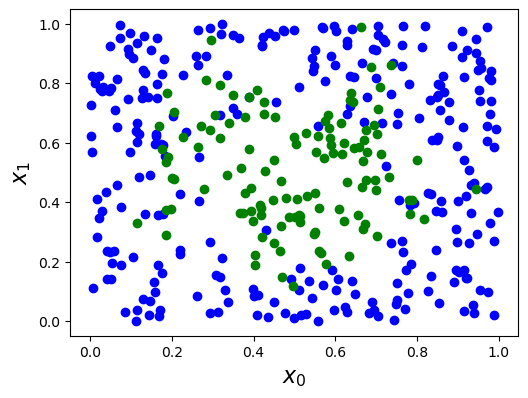

In [20]:
I0 = np.where(y==0)[0]
I1 = np.where(y==1)[0]
plt.plot(X[I0,0], X[I0,1], 'bo')
plt.plot(X[I1,0], X[I1,1], 'go')
plt.xlabel('$x_0$', fontsize=16)
plt.ylabel('$x_1$', fontsize=16)
plt.subplots_adjust(bottom=0.2, left=0.2)

## Creating a Simple Neural Network.

We see that the above points are not linearly separable.  We will see if we can build a simple neural network classifier to find a good decision region.

Neural networks in PyTorch are represented as `class` derived from the `nn.Module`.  In the constructor of the class, we define the layers of the neural network.  In this case, there are four layers:
*  A fully connected linear layer (FC1)
*  An activation layer with sigmoids (activation)
*  A second fully connected layer (FC2)
*  A sigmoid output since we are performing binary classification
The dimensions are passed in the contructor.

The `forward()` method then take the input through the steps in the neural network to create the output.

In [ ]:

# Define the neural network architecture
class Net(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.activation = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x


We next create an instance of the neural network for our problem.  Note that there is a single output since we are performing binary classification.


In [ ]:
nin = nx  # Number of inputs
nh = 4   # Number of hidden units

model = Net(nin, nh)

# Print a summary
print(model)

We can also print the number of parameters per layer

In [ ]:
# Iterate through the model's layers and print parameter counts
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.numel())

## PyTorch Tensors

Arrays in PyTorch are stored as *Tensors*, which are basically multi-dimensional arrays.  For the most part, the syntax is identical to numpy.  Pytorch provides an [excellent video](https://pytorch.org/tutorials/beginner/introyt/tensors_deeper_tutorial.html).  

Below are some common examples.

In [ ]:
# Create a 1D tensor
x1 = torch.tensor([1,2,3])

# Create a 2D tensor
x2 = torch.tensor([[1,2,3],[4,5,6]])

# Indexing a tensor
x3 = torch.arange(12).reshape(4,3)
y3 = x3[1:3,1:]
print(x3)
print(y3)


You can also convert to and from numpy easily.

In [ ]:
# Convert from numpy to torch and back
x_numpy = x3.numpy()
x_torch = torch.from_numpy(x_numpy)



## Training the Network

To train the network, we have to select an optimizer and a loss function.  Since this is a binary classification problem, we select the `BCELoss` loss.  For the optimizer, `Adam` tends to works well over a wide range of problems and is a good starting point.  


In [ ]:
# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.03)

Next, we have to convert the `numpy` arrays `X,y` to `torch` tensors and load them into a `DataLoader` class that can provide mini-batches of data.  

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Convert your data to PyTorch tensors.
# The targets, y_torch, are reshaped to (n_samples,1)
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)[:,None]

# Create a TensorDataset
dataset = TensorDataset(X_torch, y_torch)

# Create a DataLoader
batch_size = 100
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
y_int = y_torch.to(torch.int64)

Now we will run the data over many epochs to train.


In [ ]:
# Create arrays to store values
lossval = []
epochval = []
accval = []

# Training loop with DataLoader
num_epochs = 1000
for epoch in range(num_epochs):
    for inputs, labels in data_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


    # Calculate training accuracy
    with torch.no_grad():
        outputs = model(X_torch)
        predicted = (outputs > 0.5)
        accuracy = torch.sum(predicted == y_int).item() / y_int.size(0)

    # Save the values
    lossval.append(loss.item())
    epochval.append(epoch)
    accval.append(accuracy)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f},\
           Accuracy: {accuracy:.4f}')

We can now plot the loss function and accuracy as a function of the epoch number.  

In [ ]:
epochval = np.array(epochval)
lossval = np.array(lossval)
accval = np.array(accval)

plt.subplot(1,2,1)
plt.plot(epochval, lossval)
plt.grid()
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(epochval, accval)
plt.grid()
plt.xlabel('Epoch')
plt.ylabel('Training accuracy')
plt.tight_layout()
plt.show()

The printing of the accuracy every 20 epochs can result in a large number of outputs that may be unmanageable.  You can alternatively use the `tqdm` package to create a progress bar if you prefer.

In [ ]:
from tqdm import tqdm

# Use the tqdm loop
nepoch = 1000
for epoch in tqdm(range(nepoch)):
    for inputs, labels in data_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

## Visualizing Decision Regions

To see how classification rule our neural network learned, we can plot the predicted class probability as a function of `(x_0,x_1)`.  To do this, we create an input matrix `Xplot` with entries that vary over `[0,1] \times [0,1]`.  We feed that into the trained network and see what the probility `P(y=1|x)` is for each sample.  Then, we plot this like an image.

In [ ]:
# Limits to plot the response.
xmin = [0,0]
xmax = [1,1]

# Use meshgrid to create the 2D input
nplot = 100
x0plot = np.linspace(xmin[0],xmax[1],nplot)
x1plot = np.linspace(xmin[0],xmax[1],nplot)
x0mat, x1mat = np.meshgrid(x0plot,x1plot)
Xplot = np.column_stack([x0mat.ravel(), x1mat.ravel()])

# Compute the output
with torch.no_grad():
    yplot = model(torch.tensor(Xplot, dtype=torch.float32))

# Convert yplot to numpy
yplot = yplot.numpy()
yplot_mat = yplot[:,0].reshape((nplot, nplot))

# Plot the recovered region
plt.imshow(np.flipud(yplot_mat), extent=[xmin[0],xmax[0],xmin[0],xmax[1]], cmap=plt.cm.Reds)
plt.colorbar()

# Overlay the samples
I0 = np.where(y==0)[0]
I1 = np.where(y==1)[0]
plt.plot(X[I0,0], X[I0,1], 'bo')
plt.plot(X[I1,0], X[I1,1], 'go')

We see that the neural network is able to learn a nonlinear classification region matching the training data points.  To understand how this nonlinear region is realized it is useful to plot the response in the each of the hidden units.  To extract the output of an intermediate layer, we create a new model, `model_act` with the outputs set to the activation outputs in the original model and then run the `predict` command on that model.

In [ ]:
# Create a model with the activations as the output
class ModelAct(nn.Module):
    def __init__(self, original_model):
        super(ModelAct, self).__init__()
        self.fc1 = original_model.fc1
        self.activation = original_model.activation

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        return x

model_act = ModelAct(model)

# Compute the output
with torch.no_grad():
    zhid_plot = model_act(torch.tensor(Xplot, dtype=torch.float32))
zhid_plot = zhid_plot.numpy()
zhid_plot = zhid_plot.reshape((nplot, nplot,nh))

# Get the weights
w2 = model.fc2.weight.data.numpy()

fig = plt.figure(figsize=(10, 4))

for i in range(nh):

    plt.subplot(1,nh,i+1)
    zhid_ploti = np.flipud(zhid_plot[:,:,i])
    im = plt.imshow(zhid_ploti, extent=[xmin[0],xmax[0],xmin[0],xmax[1]], cmap=plt.cm.Reds)
    plt.xticks([])
    plt.yticks([])
    plt.title('zh{0:d}, W2={1:4.2f}'.format(i,w2[0,i]))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.30, 0.05, 0.4])
fig.colorbar(im, cax=cbar_ax)

Each of the hidden units produces one linear decision region.  The final nonlinear region is then formed by taking a weighted combination of these regions.

## Let us print the model parameters.

First we print the entire model weights

In [ ]:
model_params = {}
for name, param in model.named_parameters():
    model_params[name] = param.detach().numpy()

    print(f"Parameter Name: {name}")
    print(f"Shape: {param.shape}")
    print(param.detach().numpy())


Now we print individual layer weights

## Computing Gradients via Backpropagation

The tensorflow package computes all the gradients manually.  But, we show how to compute the gradients manually via back-propagation manually so you understand the mathematics.  First, we create a function that evaluates the forward pass of the neural network.  That is, it takes the inputs `X` and parameters `param` to output the loss function.

In [ ]:
def forward(param, X, y):
    """
    Computes the BCE loss for a neural network
    with one hidden layer and sigmoid activations
    """

    # Unpack the parameters
    Wh, bh, Wo, bo = param

    # Hidden layer
    Zh = X.dot(Wh) + bh[None, :]
    Uh = 1/(1+np.exp(-Zh))

    # Output layer
    zo = Uh.dot(Wo) + bo[None, :]
    zo = zo.ravel()

    # Binary cross entropy
    loss = np.sum(np.log(1+np.exp(zo))-y*zo)

    return zo, loss


We will test with some initial values.

In [ ]:
# Random initial values
Wh = np.random.normal(0,1,(nx,nh))
bh = np.random.normal(0,1,(nh,))
Wo = np.random.normal(0,1,(nh,nout))
bo = np.random.normal(0,1,(nout))
param0 = [Wh,bh,Wo,bo]

# Compute output on the training data
zo, loss = forward(param0, X, y)

## In-Class Exercise

Complete the following function that computes the loss and gradients for all the four parameters.  I have already written the gradient and loss for the output layers.  Note the use of broadcasting.  You will need to compute the gradients for the hidden layers.

In [ ]:
def loss_eval(param, X, y):
    """
    Evaluates the loss function and gradients
    for the neural network
    """

    # Unpack the parameters
    Wh, bh, Wo, bo = param

    # Hidden layer
    Zh = X.dot(Wh) + bh[None, :]
    Uh = 1/(1+np.exp(-Zh))

    # Output layer
    zo = Uh.dot(Wo) + bo[None,:]
    zo = zo.ravel()

    # Binary cross entropy
    loss = np.sum(np.log(1+np.exp(zo))-y*zo)

    # Gradient for the output layer.
    # Note the use of broadcasting
    grad_dzo = 1/(1+np.exp(-zo))-y
    grad_Wo = np.sum(Uh[:,:,None]*grad_dzo[:,None,None], axis=0)
    grad_bo = np.sum(grad_dzo)

    # TODO:  Compute gradients for the hidden layer
    # grad_Wh = ...
    # grad_bh = ...
    grad_Wh = 0
    grad_bh = 0

    # Pack the gradients
    grad = [grad_Wh, grad_bh, grad_Wo, grad_bo]

    return loss, grad



When you are done, try to test your gradient.

*  Construct a list of parameters, `param1` with values slightly perturbed from `param0`.
*  Evaluate `loss0, grad0` at `param0` and `loss1, grad1` at `param1`
*  Compute the actual difference `loss1-loss0`.
*  Compute the expected difference which is the sum of the terms: `np.sum(grad0[i]*(param1[i]-param0[i]))`.

In [ ]:
# TODO


